# Agrupamiento de los coeficientes arquetípicos

Este notebook analiza si los coeficientes \(\alpha\) obtenidos mediante AA contienen estructuras de agrupamiento adicionales a la asignación basada exclusivamente en el arquetipo dominante.

La unidad de análisis corresponde a cada curva de luz. Cuando una estrella física posee observaciones en más de un catálogo de OGLE, cada curva se mantiene como una instancia diferente, de acuerdo con la entrada utilizada por AA. Las configuraciones se seleccionan con el conjunto de validación y posteriormente se evalúan en test.

Se comparan los siguientes enfoques:

- asignación según el coeficiente \(\alpha\) máximo;
- k-means aplicado al vector completo de coeficientes;
- DBSCAN;
- HDBSCAN, si se encuentra disponible.

In [1]:
from itertools import combinations
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from itertools import combinations

from sklearn.cluster import DBSCAN, HDBSCAN, KMeans
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors


def encontrar_raiz_proyecto():
    """Busca la raíz del proyecto desde el directorio actual."""

    ruta_actual = Path.cwd().resolve()

    for ruta_candidata in (
        ruta_actual,
        *ruta_actual.parents,
    ):
        tiene_src = (
            ruta_candidata
            / "src"
        ).is_dir()

        tiene_notebooks = (
            ruta_candidata
            / "notebooks"
        ).is_dir()

        if tiene_src and tiene_notebooks:
            return ruta_candidata

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto."
    )


RUTA_PROYECTO = encontrar_raiz_proyecto()

print(
    "Raíz del proyecto:",
    RUTA_PROYECTO,
)


# Permitir que Python encuentre los módulos de src
if str(RUTA_PROYECTO) not in sys.path:
    sys.path.insert(
        0,
        str(RUTA_PROYECTO),
    )


from src.loaders import cargar_dataset

Raíz del proyecto: C:\Users\adanm\Code\tesis


In [2]:
# Rutas de la selección y evaluación corregidas
RUTA_SELECCION_TEST = (
    RUTA_PROYECTO
    / "resultados"
    / "seleccion_familias_test_corregida.csv"
)

RUTA_EVALUACION_TEST = (
    RUTA_PROYECTO
    / "resultados"
    / "evaluacion_test_corregida"
)

RUTA_ARTEFACTOS_TEST = (
    RUTA_EVALUACION_TEST
    / "artefactos"
)


# Cargar las ejecuciones seleccionadas
df_seleccion = pd.read_csv(
    RUTA_SELECCION_TEST
)


# Seleccionar las cinco ejecuciones de AA
df_aa = (
    df_seleccion
    .loc[
        df_seleccion["familia_test"]
        == "aa_principal_k5"
    ]
    .sort_values("seed_modelo")
    .reset_index(drop=True)
)


# Comprobar los archivos disponibles
comprobacion_archivos = []

for _, ejecucion in df_aa.iterrows():

    experiment_id = ejecucion["experiment_id"]

    ruta_experimento = (
        RUTA_PROYECTO
        / Path(ejecucion["ruta_experimento"])
    )

    ruta_test = (
        RUTA_ARTEFACTOS_TEST
        / experiment_id
    )

    comprobacion_archivos.append(
        {
            "experiment_id": experiment_id,
            "seed_modelo": ejecucion["seed_modelo"],
            "alphas_val": (
                ruta_experimento
                / "alphas_val.npy"
            ).exists(),
            "grupos_val": (
                ruta_experimento
                / "grupos_val.npy"
            ).exists(),
            "ids_val": (
                ruta_experimento
                / "ids_val.npy"
            ).exists(),
            "alphas_test": (
                ruta_test
                / "alphas_test.npy"
            ).exists(),
            "grupos_test": (
                ruta_test
                / "grupos_test.npy"
            ).exists(),
        }
    )


df_comprobacion_archivos = pd.DataFrame(
    comprobacion_archivos
)

display(df_comprobacion_archivos)

,experiment_id,seed_modelo,alphas_val,grupos_val,ids_val,alphas_test,grupos_test
0,130b477559867762,0,True,True,True,True,True
1,4dd949ada25b888e,1,True,True,True,True,True
2,37dedb2834a007b2,2,True,True,True,True,True
3,349e82cdd54799e0,3,True,True,True,True,True
4,976409505a67e4f6,4,True,True,True,True,True


In [3]:
# Cargar las asignaciones de validación
# de las cinco ejecuciones de AA
asignaciones_aa_val = {}
ids_val_referencia = None


for _, ejecucion in df_aa.iterrows():

    experiment_id = ejecucion["experiment_id"]

    ruta_experimento = (
        RUTA_PROYECTO
        / Path(ejecucion["ruta_experimento"])
    )

    grupos_val = np.load(
        ruta_experimento
        / "grupos_val.npy"
    )

    ids_val = np.load(
        ruta_experimento
        / "ids_val.npy",
        allow_pickle=True,
    )

    if ids_val_referencia is None:
        ids_val_referencia = ids_val

    elif not np.array_equal(
        ids_val_referencia,
        ids_val,
    ):
        raise ValueError(
            "Los identificadores de validación "
            "no coinciden entre las ejecuciones de AA."
        )

    asignaciones_aa_val[experiment_id] = {
        "seed_modelo": int(
            ejecucion["seed_modelo"]
        ),
        "grupos_val": grupos_val,
    }


# Calcular la representatividad de cada ejecución
resultados_representatividad = []

for experiment_id, contenido in (
    asignaciones_aa_val.items()
):

    ari_con_otras = []

    for otro_id, otro_contenido in (
        asignaciones_aa_val.items()
    ):

        if experiment_id == otro_id:
            continue

        ari_con_otras.append(
            adjusted_rand_score(
                contenido["grupos_val"],
                otro_contenido["grupos_val"],
            )
        )

    resultados_representatividad.append(
        {
            "experiment_id": experiment_id,
            "seed_modelo": contenido["seed_modelo"],
            "ari_medio": np.mean(ari_con_otras),
            "ari_minimo": np.min(ari_con_otras),
        }
    )


df_representatividad_aa = (
    pd.DataFrame(resultados_representatividad)
    .sort_values(
        [
            "ari_medio",
            "ari_minimo",
            "seed_modelo",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


# La primera fila corresponde a la ejecución
# más representativa
ejecucion_aa_representativa = (
    df_representatividad_aa.iloc[0]
)

EXPERIMENT_ID_AA = (
    ejecucion_aa_representativa["experiment_id"]
)

SEED_AA = int(
    ejecucion_aa_representativa["seed_modelo"]
)


display(df_representatividad_aa)

print(
    "\nEjecución representativa:",
    EXPERIMENT_ID_AA,
)

print(
    "Semilla representativa:",
    SEED_AA,
)

,experiment_id,seed_modelo,ari_medio,ari_minimo
0,976409505a67e4f6,4,0.999829,0.999658
1,130b477559867762,0,0.999829,0.999658
2,4dd949ada25b888e,1,0.999829,0.999658
3,37dedb2834a007b2,2,0.999744,0.999658
4,349e82cdd54799e0,3,0.999744,0.999658



Ejecución representativa: 976409505a67e4f6
Semilla representativa: 4


In [4]:
# Recuperar la fila de la ejecución representativa
fila_aa = (
    df_aa
    .loc[
        df_aa["experiment_id"]
        == EXPERIMENT_ID_AA
    ]
    .iloc[0]
)


# Construir las rutas correspondientes
RUTA_EXPERIMENTO_AA = (
    RUTA_PROYECTO
    / Path(fila_aa["ruta_experimento"])
)

RUTA_TEST_AA = (
    RUTA_ARTEFACTOS_TEST
    / EXPERIMENT_ID_AA
)


# Cargar coeficientes y asignaciones de validación
alphas_val = np.load(
    RUTA_EXPERIMENTO_AA
    / "alphas_val.npy"
)

grupos_val_aa = np.load(
    RUTA_EXPERIMENTO_AA
    / "grupos_val.npy"
)

ids_val = np.load(
    RUTA_EXPERIMENTO_AA
    / "ids_val.npy",
    allow_pickle=True,
)


# Cargar coeficientes y asignaciones de test
alphas_test = np.load(
    RUTA_TEST_AA
    / "alphas_test.npy"
)

grupos_test_aa = np.load(
    RUTA_TEST_AA
    / "grupos_test.npy"
)

ids_test = np.load(
    RUTA_EVALUACION_TEST
    / "ids_test.npy",
    allow_pickle=True,
)


# Cargar los metadatos del dataset
datos_mediana_50 = cargar_dataset(
    "medianas_fase_50"
)

metadata_val_original = (
    datos_mediana_50["val"]["metadata"]
    .copy()
)

metadata_test_original = (
    datos_mediana_50["test"]["metadata"]
    .copy()
)


# Ordenar los metadatos según los identificadores
# utilizados en las proyecciones de AA
metadata_val = (
    metadata_val_original
    .set_index("observacion_id")
    .loc[ids_val]
    .reset_index()
)

metadata_test = (
    metadata_test_original
    .set_index("observacion_id")
    .loc[ids_test]
    .reset_index()
)


# Comprobar las dimensiones, restricciones y asignaciones
comprobacion_datos = pd.Series(
    {
        "forma_alphas_val": alphas_val.shape,
        "forma_alphas_test": alphas_test.shape,
        "filas_metadata_val": len(metadata_val),
        "filas_metadata_test": len(metadata_test),
        "suma_minima_val": (
            alphas_val.sum(axis=1).min()
        ),
        "suma_maxima_val": (
            alphas_val.sum(axis=1).max()
        ),
        "suma_minima_test": (
            alphas_test.sum(axis=1).min()
        ),
        "suma_maxima_test": (
            alphas_test.sum(axis=1).max()
        ),
        "alpha_minimo": min(
            alphas_val.min(),
            alphas_test.min(),
        ),
        "alpha_maximo": max(
            alphas_val.max(),
            alphas_test.max(),
        ),
        "argmax_coincide_val": np.array_equal(
            np.argmax(alphas_val, axis=1),
            grupos_val_aa,
        ),
        "argmax_coincide_test": np.array_equal(
            np.argmax(alphas_test, axis=1),
            grupos_test_aa,
        ),
    },
    name="resultado",
)

display(comprobacion_datos)

forma_alphas_val        (20576, 5)
forma_alphas_test       (20537, 5)
filas_metadata_val           20576
filas_metadata_test          20537
suma_minima_val                1.0
suma_maxima_val                1.0
suma_minima_test               1.0
suma_maxima_test               1.0
alpha_minimo                   0.0
alpha_maximo                   1.0
argmax_coincide_val           True
argmax_coincide_test          True
Name: resultado, dtype: object

In [5]:
# Etiquetas reales de validación
subtipos_val = (
    metadata_val["subtipo_rrlyrae"]
    .to_numpy()
)


def calcular_pureza(
    etiquetas_reales,
    grupos,
):
    """Calcula la pureza global de una partición."""

    tabla = pd.crosstab(
        grupos,
        etiquetas_reales,
    )

    return (
        tabla.max(axis=1).sum()
        / tabla.to_numpy().sum()
    )


def evaluar_particion(
    X,
    grupos,
    etiquetas_reales,
    semilla_muestreo=0,
):
    """Calcula métricas internas y externas."""

    grupos_unicos = np.unique(grupos)
    n_grupos = len(grupos_unicos)

    if n_grupos < 2:
        silhouette = np.nan
        davies_bouldin = np.nan

    else:
        silhouette = silhouette_score(
            X,
            grupos,
            sample_size=min(
                5000,
                len(X),
            ),
            random_state=semilla_muestreo,
        )

        davies_bouldin = davies_bouldin_score(
            X,
            grupos,
        )

    return {
        "n_grupos": n_grupos,
        "pureza": calcular_pureza(
            etiquetas_reales,
            grupos,
        ),
        "ami": adjusted_mutual_info_score(
            etiquetas_reales,
            grupos,
        ),
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
    }


# Asignación según el coeficiente alpha máximo
grupos_alpha_max_val = np.argmax(
    alphas_val,
    axis=1,
)


metricas_alpha_max_val = evaluar_particion(
    alphas_val,
    grupos_alpha_max_val,
    subtipos_val,
)


display(
    pd.DataFrame(
        [
            {
                "metodo": "alpha_maximo",
                **metricas_alpha_max_val,
            }
        ]
    ).round(4)
)

,metodo,n_grupos,pureza,ami,silhouette,davies_bouldin
0,alpha_maximo,5,0.9286,0.3945,0.4157,0.8392


## Experimentos en ejecución representativa

### K-Means

In [6]:
# Valores y semillas que se evaluarán
valores_k = range(2, 9)
semillas_kmeans = [0, 1, 2, 3, 4]


resultados_kmeans_val = []
asignaciones_kmeans_val = {}


for k in valores_k:

    for semilla in semillas_kmeans:

        modelo = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=20,
            random_state=semilla,
        )

        grupos = modelo.fit_predict(
            alphas_val
        )

        metricas = evaluar_particion(
            alphas_val,
            grupos,
            subtipos_val,
        )

        resultados_kmeans_val.append(
            {
                "K": k,
                "seed_modelo": semilla,
                "inercia_por_observacion": (
                    modelo.inertia_
                    / len(alphas_val)
                ),
                **metricas,
            }
        )

        asignaciones_kmeans_val[
            (k, semilla)
        ] = grupos

    print(
        f"K={k} completado"
    )


df_kmeans_val = pd.DataFrame(
    resultados_kmeans_val
)


# Calcular estabilidad entre semillas para cada K
resultados_estabilidad = []

for k in valores_k:

    valores_ari = []

    for semilla_1, semilla_2 in combinations(
        semillas_kmeans,
        2,
    ):

        valores_ari.append(
            adjusted_rand_score(
                asignaciones_kmeans_val[
                    (k, semilla_1)
                ],
                asignaciones_kmeans_val[
                    (k, semilla_2)
                ],
            )
        )

    resultados_estabilidad.append(
        {
            "K": k,
            "ari_semillas_media": np.mean(
                valores_ari
            ),
            "ari_semillas_std": np.std(
                valores_ari,
                ddof=1,
            ),
            "ari_semillas_minimo": np.min(
                valores_ari
            ),
        }
    )


df_estabilidad_kmeans_val = pd.DataFrame(
    resultados_estabilidad
)


# Resumir las cinco ejecuciones de cada K
resumen_kmeans_val = (
    df_kmeans_val
    .groupby("K")
    .agg(
        n_ejecuciones=(
            "seed_modelo",
            "size",
        ),
        inercia_media=(
            "inercia_por_observacion",
            "mean",
        ),
        inercia_std=(
            "inercia_por_observacion",
            "std",
        ),
        pureza_media=(
            "pureza",
            "mean",
        ),
        pureza_std=(
            "pureza",
            "std",
        ),
        ami_media=(
            "ami",
            "mean",
        ),
        ami_std=(
            "ami",
            "std",
        ),
        silhouette_media=(
            "silhouette",
            "mean",
        ),
        silhouette_std=(
            "silhouette",
            "std",
        ),
        davies_bouldin_media=(
            "davies_bouldin",
            "mean",
        ),
        davies_bouldin_std=(
            "davies_bouldin",
            "std",
        ),
    )
    .reset_index()
    .merge(
        df_estabilidad_kmeans_val,
        on="K",
        how="left",
        validate="one_to_one",
    )
)


display(
    resumen_kmeans_val.round(4)
)

K=2 completado
K=3 completado
K=4 completado
K=5 completado
K=6 completado
K=7 completado
K=8 completado


,K,n_ejecuciones,inercia_media,inercia_std,pureza_media,pureza_std,ami_media,ami_std,silhouette_media,silhouette_std,davies_bouldin_media,davies_bouldin_std,ari_semillas_media,ari_semillas_std,ari_semillas_minimo
0,2,5,0.1518,0.0,0.9187,0.0003,0.6169,0.0009,0.4386,0.0000,0.9616,0.0006,0.9986,0.0011,0.9972
1,3,5,0.0930,0.0,0.9255,0.0000,0.4787,0.0000,0.4551,0.0000,0.8942,0.0000,0.9999,0.0001,0.9998
2,4,5,0.0649,0.0,0.9252,0.0001,0.4016,0.0001,0.4461,0.0000,0.7960,0.0001,0.9977,0.0011,0.9958
3,5,5,0.0560,0.0,0.9254,0.0000,0.3730,0.0000,0.4363,0.0001,0.8390,0.0004,0.9981,0.0013,0.9965
4,6,5,0.0479,0.0,0.9319,0.0001,0.3823,0.0011,0.4069,0.0005,0.9496,0.0042,0.9895,0.0089,0.9776
5,7,5,0.0407,0.0,0.9301,0.0005,0.3676,0.0005,0.4138,0.0002,0.8562,0.0018,0.9907,0.0042,0.9838
6,8,5,0.0340,0.0,0.9328,0.0000,0.3468,0.0000,0.4159,0.0002,0.8363,0.0004,0.9917,0.0048,0.9861


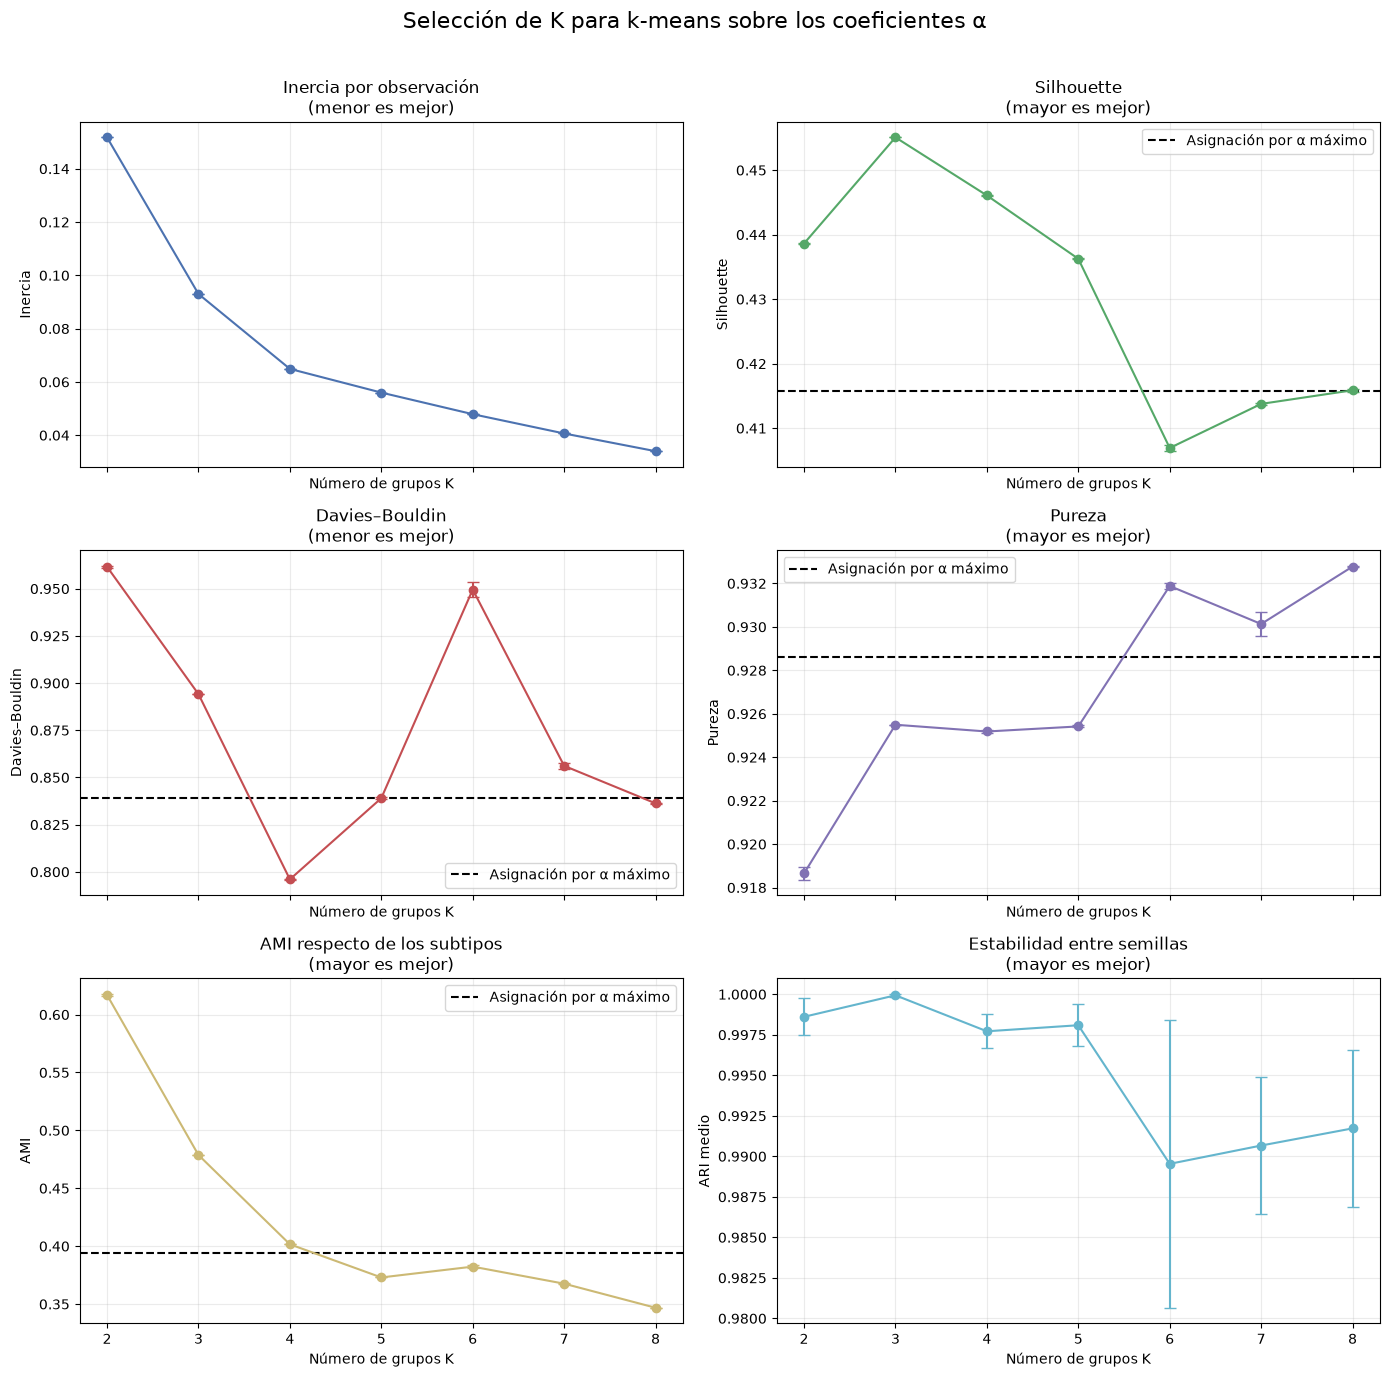

In [7]:
# Ordenar los resultados por número de grupos
datos_grafico = (
    resumen_kmeans_val
    .sort_values("K")
    .reset_index(drop=True)
)


# Crear la carpeta de resultados
RUTA_RESULTADOS = (
    RUTA_PROYECTO
    / "resultados"
    / "clustering_alfas"
)

RUTA_RESULTADOS.mkdir(
    parents=True,
    exist_ok=True,
)


# Crear la figura
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 14),
    sharex=True,
)

axes = axes.flatten()


# 1. Inercia
axes[0].errorbar(
    datos_grafico["K"],
    datos_grafico["inercia_media"],
    yerr=datos_grafico["inercia_std"],
    marker="o",
    capsize=4,
    color="#4C72B0",
)

axes[0].set_title(
    "Inercia por observación\n(menor es mejor)"
)

axes[0].set_ylabel(
    "Inercia"
)


# 2. Silhouette
axes[1].errorbar(
    datos_grafico["K"],
    datos_grafico["silhouette_media"],
    yerr=datos_grafico["silhouette_std"],
    marker="o",
    capsize=4,
    color="#55A868",
)

axes[1].axhline(
    metricas_alpha_max_val["silhouette"],
    color="black",
    linestyle="--",
    label="Asignación por α máximo",
)

axes[1].set_title(
    "Silhouette\n(mayor es mejor)"
)

axes[1].set_ylabel(
    "Silhouette"
)

axes[1].legend()


# 3. Davies–Bouldin
axes[2].errorbar(
    datos_grafico["K"],
    datos_grafico["davies_bouldin_media"],
    yerr=datos_grafico["davies_bouldin_std"],
    marker="o",
    capsize=4,
    color="#C44E52",
)

axes[2].axhline(
    metricas_alpha_max_val["davies_bouldin"],
    color="black",
    linestyle="--",
    label="Asignación por α máximo",
)

axes[2].set_title(
    "Davies–Bouldin\n(menor es mejor)"
)

axes[2].set_ylabel(
    "Davies–Bouldin"
)

axes[2].legend()


# 4. Pureza
axes[3].errorbar(
    datos_grafico["K"],
    datos_grafico["pureza_media"],
    yerr=datos_grafico["pureza_std"],
    marker="o",
    capsize=4,
    color="#8172B3",
)

axes[3].axhline(
    metricas_alpha_max_val["pureza"],
    color="black",
    linestyle="--",
    label="Asignación por α máximo",
)

axes[3].set_title(
    "Pureza\n(mayor es mejor)"
)

axes[3].set_ylabel(
    "Pureza"
)

axes[3].legend()


# 5. AMI
axes[4].errorbar(
    datos_grafico["K"],
    datos_grafico["ami_media"],
    yerr=datos_grafico["ami_std"],
    marker="o",
    capsize=4,
    color="#CCB974",
)

axes[4].axhline(
    metricas_alpha_max_val["ami"],
    color="black",
    linestyle="--",
    label="Asignación por α máximo",
)

axes[4].set_title(
    "AMI respecto de los subtipos\n(mayor es mejor)"
)

axes[4].set_ylabel(
    "AMI"
)

axes[4].legend()


# 6. Estabilidad entre semillas
axes[5].errorbar(
    datos_grafico["K"],
    datos_grafico["ari_semillas_media"],
    yerr=datos_grafico["ari_semillas_std"],
    marker="o",
    capsize=4,
    color="#64B5CD",
)

axes[5].set_title(
    "Estabilidad entre semillas\n(mayor es mejor)"
)

axes[5].set_ylabel(
    "ARI medio"
)


# Configuración común
for ax in axes:

    ax.set_xlabel(
        "Número de grupos K"
    )

    ax.set_xticks(
        datos_grafico["K"]
    )

    ax.grid(
        alpha=0.25
    )


fig.suptitle(
    "Selección de K para k-means sobre los coeficientes α",
    fontsize=16,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)


plt.savefig(
    RUTA_RESULTADOS
    / "seleccion_kmeans_validacion.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [8]:
# Configuraciones que analizaremos en detalle
valores_k_interes = [2, 3, 4]


# Seleccionar la semilla más representativa de cada K
resultados_centralidad = []

for k in valores_k_interes:

    for semilla in semillas_kmeans:

        ari_con_otras = []

        for otra_semilla in semillas_kmeans:

            if semilla == otra_semilla:
                continue

            ari_con_otras.append(
                adjusted_rand_score(
                    asignaciones_kmeans_val[
                        (k, semilla)
                    ],
                    asignaciones_kmeans_val[
                        (k, otra_semilla)
                    ],
                )
            )

        inercia = (
            df_kmeans_val
            .loc[
                (
                    df_kmeans_val["K"] == k
                )
                &
                (
                    df_kmeans_val["seed_modelo"]
                    == semilla
                ),
                "inercia_por_observacion",
            ]
            .iloc[0]
        )

        resultados_centralidad.append(
            {
                "K": k,
                "seed_modelo": semilla,
                "ari_medio_con_otras": np.mean(
                    ari_con_otras
                ),
                "inercia": inercia,
            }
        )


df_centralidad_kmeans = pd.DataFrame(
    resultados_centralidad
)


semillas_representativas = (
    df_centralidad_kmeans
    .sort_values(
        [
            "K",
            "ari_medio_con_otras",
            "inercia",
            "seed_modelo",
        ],
        ascending=[
            True,
            False,
            True,
            True,
        ],
    )
    .groupby(
        "K",
        as_index=False,
    )
    .head(1)
    .reset_index(drop=True)
)


# Construir las tablas de composición
tablas_composicion = []
tablas_distribucion = []


for _, fila in semillas_representativas.iterrows():

    k = int(fila["K"])
    semilla = int(fila["seed_modelo"])

    grupos = asignaciones_kmeans_val[
        (k, semilla)
    ]

    conteos = pd.crosstab(
        grupos + 1,
        subtipos_val,
    )

    conteos = conteos.reindex(
        columns=[
            "RRab",
            "RRc",
            "RRd",
        ],
        fill_value=0,
    )


    # Porcentaje de cada subtipo dentro del grupo
    composicion = (
        conteos
        .div(
            conteos.sum(axis=1),
            axis=0,
        )
        .mul(100)
        .round(2)
    )

    composicion.insert(
        0,
        "n_total",
        conteos.sum(axis=1),
    )

    composicion.insert(
        0,
        "grupo",
        composicion.index,
    )

    composicion.insert(
        0,
        "K",
        k,
    )

    tablas_composicion.append(
        composicion.reset_index(drop=True)
    )


    # Distribución de cada subtipo entre los grupos
    distribucion = (
        conteos
        .div(
            conteos.sum(axis=0),
            axis=1,
        )
        .mul(100)
        .round(2)
    )

    distribucion.insert(
        0,
        "grupo",
        distribucion.index,
    )

    distribucion.insert(
        0,
        "K",
        k,
    )

    tablas_distribucion.append(
        distribucion.reset_index(drop=True)
    )


tabla_composicion_kmeans = pd.concat(
    tablas_composicion,
    ignore_index=True,
)

tabla_distribucion_kmeans = pd.concat(
    tablas_distribucion,
    ignore_index=True,
)


print("Semillas representativas:")

display(
    semillas_representativas.round(4)
)


print(
    "\nComposición interna de cada grupo (%):"
)

display(
    tabla_composicion_kmeans
)


print(
    "\nDistribución de cada subtipo entre los grupos (%):"
)

display(
    tabla_distribucion_kmeans
)

Semillas representativas:


,K,seed_modelo,ari_medio_con_otras,inercia
0,2,4,0.9990,0.1518
1,3,1,1.0000,0.0930
2,4,2,0.9983,0.0649



Composición interna de cada grupo (%):


col_0,K,grupo,n_total,RRab,RRc,RRd
0,2,1,14242,97.96,0.84,1.20
1,2,2,6334,14.89,78.21,6.90
2,3,1,10169,99.55,0.17,0.29
3,3,2,5072,6.37,88.15,5.48
4,3,3,5335,83.39,10.97,5.64
5,4,1,5468,99.63,0.33,0.04
6,4,2,5623,98.61,0.36,1.03
7,4,3,4464,80.53,13.17,6.29
8,4,4,5021,6.11,88.57,5.32



Distribución de cada subtipo entre los grupos (%):


col_0,K,grupo,RRab,RRc,RRd
0,2,1,93.67,2.35,28.12
1,2,2,6.33,97.65,71.88
2,3,1,67.96,0.34,4.77
3,3,2,2.17,88.13,45.72
4,3,3,29.87,11.53,49.51
5,4,1,36.58,0.35,0.33
6,4,2,37.23,0.39,9.54
7,4,3,24.14,11.59,46.22
8,4,4,2.06,87.66,43.91


### DBSCAN

min_samples,10,25,50
percentil,,,
0.500,0.02312,0.03487,0.04645
0.750,0.04293,0.05949,0.07537
0.900,0.06345,0.08520,0.10560
0.950,0.07993,0.10641,0.13054
0.975,0.09852,0.12997,0.15903
0.990,0.12870,0.16558,0.19969
0.995,0.14655,0.18785,0.22907


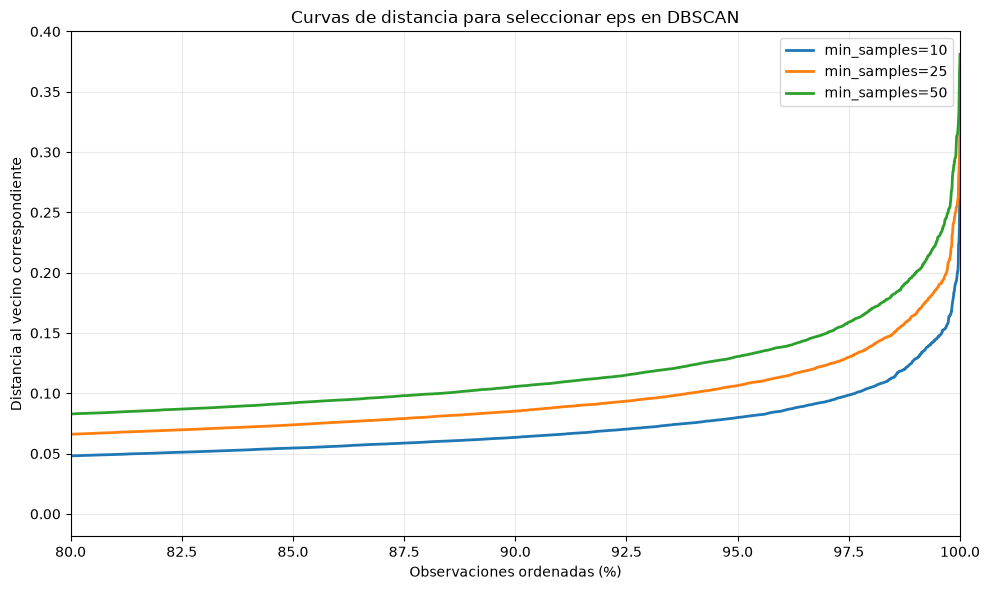

In [9]:
# Valores de min_samples que examinaremos
valores_min_samples = [
    10,
    25,
    50,
]


# Percentiles utilizados para resumir
# las distancias al vecino correspondiente
percentiles_distancia = [
    0.50,
    0.75,
    0.90,
    0.95,
    0.975,
    0.99,
    0.995,
]


resultados_distancias = []
distancias_ordenadas = {}


for min_samples in valores_min_samples:

    vecinos = NearestNeighbors(
        n_neighbors=min_samples,
        metric="euclidean",
        n_jobs=-1,
    )

    vecinos.fit(
        alphas_val
    )

    distancias, _ = vecinos.kneighbors(
        alphas_val
    )

    # Distancia hasta el vecino número min_samples
    distancia_k = distancias[:, -1]

    distancias_ordenadas[min_samples] = np.sort(
        distancia_k
    )

    for percentil in percentiles_distancia:

        resultados_distancias.append(
            {
                "min_samples": min_samples,
                "percentil": percentil,
                "distancia": np.quantile(
                    distancia_k,
                    percentil,
                ),
            }
        )


tabla_distancias_vecinos = pd.DataFrame(
    resultados_distancias
)


display(
    tabla_distancias_vecinos
    .pivot(
        index="percentil",
        columns="min_samples",
        values="distancia",
    )
    .round(5)
)


# Visualizar las curvas de distancia
fig, ax = plt.subplots(
    figsize=(10, 6)
)


for min_samples in valores_min_samples:

    distancias = distancias_ordenadas[
        min_samples
    ]

    porcentaje_observaciones = np.linspace(
        0,
        100,
        len(distancias),
    )

    ax.plot(
        porcentaje_observaciones,
        distancias,
        linewidth=2,
        label=(
            f"min_samples={min_samples}"
        ),
    )


ax.set_xlabel(
    "Observaciones ordenadas (%)"
)

ax.set_ylabel(
    "Distancia al vecino correspondiente"
)

ax.set_title(
    "Curvas de distancia para seleccionar eps en DBSCAN"
)

ax.set_xlim(
    80,
    100,
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.tight_layout()

plt.savefig(
    RUTA_RESULTADOS
    / "distancias_vecinos_dbscan.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [10]:
def evaluar_dbscan(
    X,
    grupos,
    etiquetas_reales,
):
    """Evalúa una partición de DBSCAN considerando el ruido."""

    mascara_agrupada = grupos != -1

    grupos_validos = grupos[
        mascara_agrupada
    ]

    etiquetas_validas = etiquetas_reales[
        mascara_agrupada
    ]

    X_valido = X[
        mascara_agrupada
    ]

    grupos_unicos = np.unique(
        grupos_validos
    )

    n_grupos = len(grupos_unicos)
    n_ruido = np.sum(~mascara_agrupada)

    cobertura = (
        mascara_agrupada.mean()
    )

    if len(grupos_validos) > 0:

        pureza = calcular_pureza(
            etiquetas_validas,
            grupos_validos,
        )

        ami_sin_ruido = (
            adjusted_mutual_info_score(
                etiquetas_validas,
                grupos_validos,
            )
        )

    else:
        pureza = np.nan
        ami_sin_ruido = np.nan


    # AMI considerando el ruido como una categoría adicional
    ami_total = adjusted_mutual_info_score(
        etiquetas_reales,
        grupos,
    )


    if n_grupos >= 2:

        silhouette = silhouette_score(
            X_valido,
            grupos_validos,
            sample_size=min(
                5000,
                len(X_valido),
            ),
            random_state=0,
        )

        davies_bouldin = davies_bouldin_score(
            X_valido,
            grupos_validos,
        )

        tamanos = pd.Series(
            grupos_validos
        ).value_counts()

        grupo_mayor_pct = (
            tamanos.max()
            / len(grupos_validos)
            * 100
        )

        grupo_menor = tamanos.min()

    else:
        silhouette = np.nan
        davies_bouldin = np.nan
        grupo_mayor_pct = np.nan
        grupo_menor = np.nan


    return {
        "n_grupos": n_grupos,
        "n_ruido": n_ruido,
        "cobertura": cobertura,
        "pureza_sin_ruido": pureza,
        "ami_sin_ruido": ami_sin_ruido,
        "ami_total": ami_total,
        "silhouette_sin_ruido": silhouette,
        "davies_bouldin_sin_ruido": davies_bouldin,
        "grupo_mayor_pct": grupo_mayor_pct,
        "grupo_menor": grupo_menor,
    }


# Percentiles utilizados para generar valores de eps
percentiles_eps = [
    0.90,
    0.95,
    0.975,
    0.99,
]


resultados_dbscan_val = []
asignaciones_dbscan_val = {}


for min_samples in valores_min_samples:

    distancias = distancias_ordenadas[
        min_samples
    ]

    for percentil in percentiles_eps:

        eps = np.quantile(
            distancias,
            percentil,
        )

        modelo_dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean",
            n_jobs=-1,
        )

        grupos = modelo_dbscan.fit_predict(
            alphas_val
        )

        metricas = evaluar_dbscan(
            alphas_val,
            grupos,
            subtipos_val,
        )

        resultados_dbscan_val.append(
            {
                "min_samples": min_samples,
                "percentil_eps": percentil,
                "eps": eps,
                **metricas,
            }
        )

        asignaciones_dbscan_val[
            (
                min_samples,
                percentil,
            )
        ] = grupos

        print(
            "Completado:",
            f"min_samples={min_samples},",
            f"percentil={percentil}",
        )


df_dbscan_val = pd.DataFrame(
    resultados_dbscan_val
)


display(
    df_dbscan_val[
        [
            "min_samples",
            "percentil_eps",
            "eps",
            "n_grupos",
            "cobertura",
            "pureza_sin_ruido",
            "ami_sin_ruido",
            "ami_total",
            "silhouette_sin_ruido",
            "davies_bouldin_sin_ruido",
            "grupo_mayor_pct",
            "grupo_menor",
        ]
    ]
    .sort_values(
        [
            "min_samples",
            "percentil_eps",
        ]
    )
    .round(4)
)

Completado: min_samples=10, percentil=0.9
Completado: min_samples=10, percentil=0.95
Completado: min_samples=10, percentil=0.975
Completado: min_samples=10, percentil=0.99
Completado: min_samples=25, percentil=0.9
Completado: min_samples=25, percentil=0.95
Completado: min_samples=25, percentil=0.975
Completado: min_samples=25, percentil=0.99
Completado: min_samples=50, percentil=0.9
Completado: min_samples=50, percentil=0.95
Completado: min_samples=50, percentil=0.975
Completado: min_samples=50, percentil=0.99


,min_samples,percentil_eps,eps,n_grupos,cobertura,pureza_sin_ruido,ami_sin_ruido,ami_total,silhouette_sin_ruido,davies_bouldin_sin_ruido,grupo_mayor_pct,grupo_menor
0,10,0.900,0.0634,3,0.9439,0.7452,0.0047,0.0475,-0.0542,1.0673,99.7889,9.0
1,10,0.950,0.0799,2,0.9748,0.7344,0.0015,0.0290,0.0859,1.0809,99.8953,21.0
2,10,0.975,0.0985,1,0.9881,0.7290,0.0000,0.0153,NaN,NaN,NaN,NaN
3,10,0.990,0.1287,1,0.9972,0.7251,0.0000,0.0041,NaN,NaN,NaN,NaN
4,25,0.900,0.0852,2,0.9534,0.7432,0.0037,0.0483,0.0481,1.1549,99.8624,27.0
5,25,0.950,0.1064,1,0.9793,0.7331,0.0000,0.0264,NaN,NaN,NaN,NaN
6,25,0.975,0.1300,1,0.9916,0.7278,0.0000,0.0123,NaN,NaN,NaN,NaN
7,25,0.990,0.1656,1,0.9985,0.7247,0.0000,0.0027,NaN,NaN,NaN,NaN
8,50,0.900,0.1056,1,0.9600,0.7412,0.0000,0.0457,NaN,NaN,NaN,NaN
9,50,0.950,0.1305,1,0.9825,0.7321,0.0000,0.0236,NaN,NaN,NaN,NaN


In [11]:
# Explorar valores de eps más restrictivos
percentiles_eps_bajos = [
    0.50,
    0.60,
    0.70,
    0.80,
    0.85,
]


resultados_dbscan_bajos = []


for min_samples in valores_min_samples:

    distancias = distancias_ordenadas[
        min_samples
    ]

    for percentil in percentiles_eps_bajos:

        eps = np.quantile(
            distancias,
            percentil,
        )

        modelo_dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean",
            n_jobs=-1,
        )

        grupos = modelo_dbscan.fit_predict(
            alphas_val
        )

        metricas = evaluar_dbscan(
            alphas_val,
            grupos,
            subtipos_val,
        )

        resultados_dbscan_bajos.append(
            {
                "min_samples": min_samples,
                "percentil_eps": percentil,
                "eps": eps,
                **metricas,
            }
        )

        asignaciones_dbscan_val[
            (
                min_samples,
                percentil,
            )
        ] = grupos

        print(
            "Completado:",
            f"min_samples={min_samples},",
            f"percentil={percentil}",
        )


# Unir ambas exploraciones
df_dbscan_val_ampliado = (
    pd.concat(
        [
            df_dbscan_val,
            pd.DataFrame(
                resultados_dbscan_bajos
            ),
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        [
            "min_samples",
            "percentil_eps",
        ]
    )
    .sort_values(
        [
            "min_samples",
            "percentil_eps",
        ]
    )
    .reset_index(drop=True)
)


display(
    df_dbscan_val_ampliado[
        [
            "min_samples",
            "percentil_eps",
            "eps",
            "n_grupos",
            "cobertura",
            "pureza_sin_ruido",
            "ami_sin_ruido",
            "ami_total",
            "silhouette_sin_ruido",
            "davies_bouldin_sin_ruido",
            "grupo_mayor_pct",
            "grupo_menor",
        ]
    ].round(4)
)

Completado: min_samples=10, percentil=0.5
Completado: min_samples=10, percentil=0.6
Completado: min_samples=10, percentil=0.7
Completado: min_samples=10, percentil=0.8
Completado: min_samples=10, percentil=0.85
Completado: min_samples=25, percentil=0.5
Completado: min_samples=25, percentil=0.6
Completado: min_samples=25, percentil=0.7
Completado: min_samples=25, percentil=0.8
Completado: min_samples=25, percentil=0.85
Completado: min_samples=50, percentil=0.5
Completado: min_samples=50, percentil=0.6
Completado: min_samples=50, percentil=0.7
Completado: min_samples=50, percentil=0.8
Completado: min_samples=50, percentil=0.85


,min_samples,percentil_eps,eps,n_grupos,cobertura,pureza_sin_ruido,ami_sin_ruido,ami_total,silhouette_sin_ruido,davies_bouldin_sin_ruido,grupo_mayor_pct,grupo_menor
0,10,0.500,0.0231,45,0.5706,0.9971,0.6383,0.3183,-0.4656,1.0276,78.6882,6.0
1,10,0.600,0.0299,36,0.6795,0.9893,0.7020,0.3909,-0.2353,0.8899,77.8414,5.0
2,10,0.700,0.0380,19,0.7757,0.9768,0.7577,0.4626,-0.1525,1.4548,76.7997,2.0
3,10,0.800,0.0481,9,0.8715,0.7632,0.0164,0.0709,-0.1762,1.1643,99.4144,8.0
4,10,0.850,0.0546,9,0.9098,0.7546,0.0169,0.0643,-0.3750,1.2837,99.4178,8.0
5,10,0.900,0.0634,3,0.9439,0.7452,0.0047,0.0475,-0.0542,1.0673,99.7889,9.0
6,10,0.950,0.0799,2,0.9748,0.7344,0.0015,0.0290,0.0859,1.0809,99.8953,21.0
7,10,0.975,0.0985,1,0.9881,0.7290,0.0000,0.0153,NaN,NaN,NaN,NaN
8,10,0.990,0.1287,1,0.9972,0.7251,0.0000,0.0041,NaN,NaN,NaN,NaN
9,25,0.500,0.0349,9,0.5844,0.9978,0.8362,0.3640,-0.2254,1.0819,80.8799,25.0


In [12]:
# Configuración seleccionada de DBSCAN
MIN_SAMPLES_DBSCAN = 50
PERCENTIL_EPS_DBSCAN = 0.70

EPS_DBSCAN = np.quantile(
    distancias_ordenadas[
        MIN_SAMPLES_DBSCAN
    ],
    PERCENTIL_EPS_DBSCAN,
)


# Recuperar las asignaciones de validación
grupos_dbscan_val = asignaciones_dbscan_val[
    (
        MIN_SAMPLES_DBSCAN,
        PERCENTIL_EPS_DBSCAN,
    )
]


# Crear nombres legibles para los grupos
nombres_grupos_dbscan = np.where(
    grupos_dbscan_val == -1,
    "Ruido",
    np.char.add(
        "Grupo ",
        (
            grupos_dbscan_val + 1
        ).astype(str),
    ),
)


# Construir tabla base
df_dbscan_asignaciones = pd.DataFrame(
    {
        "grupo_dbscan": nombres_grupos_dbscan,
        "subtipo_rrlyrae": subtipos_val,
    }
)


# Conteos por grupo y subtipo
conteos_dbscan = pd.crosstab(
    df_dbscan_asignaciones["grupo_dbscan"],
    df_dbscan_asignaciones["subtipo_rrlyrae"],
)

conteos_dbscan = conteos_dbscan.reindex(
    columns=[
        "RRab",
        "RRc",
        "RRd",
    ],
    fill_value=0,
)


# Composición interna de cada grupo
composicion_dbscan = (
    conteos_dbscan
    .div(
        conteos_dbscan.sum(axis=1),
        axis=0,
    )
    .mul(100)
    .round(2)
)

composicion_dbscan.insert(
    0,
    "n_total",
    conteos_dbscan.sum(axis=1),
)


# Distribución de cada subtipo
distribucion_dbscan = (
    conteos_dbscan
    .div(
        conteos_dbscan.sum(axis=0),
        axis=1,
    )
    .mul(100)
    .round(2)
)


# Calcular medidas de mezcla arquetípica
alphas_ordenados_val = np.sort(
    alphas_val,
    axis=1,
)[:, ::-1]

alphas_seguras_val = np.clip(
    alphas_val,
    1e-12,
    1,
)

entropia_val = (
    -np.sum(
        alphas_seguras_val
        * np.log(alphas_seguras_val),
        axis=1,
    )
    / np.log(alphas_val.shape[1])
)


df_mezcla_dbscan = pd.DataFrame(
    {
        "grupo_dbscan": nombres_grupos_dbscan,
        "alpha_maximo": (
            alphas_ordenados_val[:, 0]
        ),
        "margen_dominancia": (
            alphas_ordenados_val[:, 0]
            - alphas_ordenados_val[:, 1]
        ),
        "entropia_normalizada": entropia_val,
    }
)


resumen_mezcla_dbscan = (
    df_mezcla_dbscan
    .groupby("grupo_dbscan")
    .agg(
        n_observaciones=(
            "alpha_maximo",
            "size",
        ),
        alpha_maximo_medio=(
            "alpha_maximo",
            "mean",
        ),
        margen_medio=(
            "margen_dominancia",
            "mean",
        ),
        entropia_media=(
            "entropia_normalizada",
            "mean",
        ),
    )
    .round(4)
)


print(
    "Configuración seleccionada:",
    f"eps={EPS_DBSCAN:.4f},",
    f"min_samples={MIN_SAMPLES_DBSCAN}",
)


print(
    "\nComposición interna de cada grupo (%):"
)

display(composicion_dbscan)


print(
    "\nDistribución de cada subtipo (%):"
)

display(distribucion_dbscan)


print(
    "\nGrado de mezcla arquetípica:"
)

display(resumen_mezcla_dbscan)

Configuración seleccionada: eps=0.0687, min_samples=50

Composición interna de cada grupo (%):


subtipo_rrlyrae,n_total,RRab,RRc,RRd
grupo_dbscan,,,,
Grupo 1,12923,99.83,0.09,0.08
Grupo 2,3820,7.41,90.39,2.20
Ruido,3833,44.64,41.95,13.41



Distribución de cada subtipo (%):


subtipo_rrlyrae,RRab,RRc,RRd
grupo_dbscan,,,
Grupo 1,86.61,0.24,1.64
Grupo 2,1.90,68.07,13.82
Ruido,11.49,31.70,84.54



Grado de mezcla arquetípica:


,n_observaciones,alpha_maximo_medio,margen_medio,entropia_media
grupo_dbscan,,,,
Grupo 1,12923,0.6130,0.2938,0.4919
Grupo 2,3820,0.6927,0.4508,0.4509
Ruido,3833,0.5276,0.2639,0.6708


### HDBSCAN


In [13]:
# Valores que se evaluarán con HDBSCAN
valores_min_cluster_size = [
    50,
    100,
    250,
    500,
]

valores_min_samples_hdbscan = [
    10,
    25,
    50,
]


resultados_hdbscan_val = []
asignaciones_hdbscan_val = {}


for min_cluster_size in valores_min_cluster_size:

    for min_samples in valores_min_samples_hdbscan:

        modelo_hdbscan = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom",
            allow_single_cluster=False,
            n_jobs=-1,
        )

        grupos = modelo_hdbscan.fit_predict(
            alphas_val
        )

        metricas = evaluar_dbscan(
            alphas_val,
            grupos,
            subtipos_val,
        )

        # Intensidad media de pertenencia
        probabilidades = (
            modelo_hdbscan.probabilities_
        )

        mascara_agrupada = grupos != -1

        if mascara_agrupada.any():
            probabilidad_media = (
                probabilidades[
                    mascara_agrupada
                ].mean()
            )
        else:
            probabilidad_media = np.nan

        resultados_hdbscan_val.append(
            {
                "min_cluster_size": (
                    min_cluster_size
                ),
                "min_samples": min_samples,
                "metodo_seleccion": "eom",
                "probabilidad_media": (
                    probabilidad_media
                ),
                **metricas,
            }
        )

        asignaciones_hdbscan_val[
            (
                min_cluster_size,
                min_samples,
            )
        ] = grupos

        print(
            "Completado:",
            (
                f"min_cluster_size="
                f"{min_cluster_size},"
            ),
            f"min_samples={min_samples}",
        )


df_hdbscan_val = pd.DataFrame(
    resultados_hdbscan_val
)


display(
    df_hdbscan_val[
        [
            "min_cluster_size",
            "min_samples",
            "n_grupos",
            "cobertura",
            "pureza_sin_ruido",
            "ami_sin_ruido",
            "ami_total",
            "silhouette_sin_ruido",
            "davies_bouldin_sin_ruido",
            "grupo_mayor_pct",
            "grupo_menor",
            "probabilidad_media",
        ]
    ]
    .sort_values(
        [
            "min_cluster_size",
            "min_samples",
        ]
    )
    .round(4)
)

c:\Users\adanm\Code\tesis\venv-tesis2\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Completado: min_cluster_size=50, min_samples=10


c:\Users\adanm\Code\tesis\venv-tesis2\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Completado: min_cluster_size=50, min_samples=25


c:\Users\adanm\Code\tesis\venv-tesis2\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


...

c:\Users\adanm\Code\tesis\venv-tesis2\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Completado: min_cluster_size=500, min_samples=25


c:\Users\adanm\Code\tesis\venv-tesis2\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Completado: min_cluster_size=500, min_samples=50


,min_cluster_size,min_samples,n_grupos,cobertura,pureza_sin_ruido,ami_sin_ruido,ami_total,silhouette_sin_ruido,davies_bouldin_sin_ruido,grupo_mayor_pct,grupo_menor,probabilidad_media
0,50,10,15,0.3868,0.9926,0.5032,0.2216,0.0843,0.7412,59.2611,50,0.8055
1,50,25,9,0.3786,0.9932,0.5720,0.2243,0.3167,0.6159,66.0847,57,0.7986
2,50,50,9,0.3419,0.9960,0.5664,0.2006,0.3925,0.4352,74.8081,65,0.8067
3,100,10,10,0.4218,0.9932,0.5326,0.2361,0.0936,0.7994,62.1457,106,0.7225
4,100,25,8,0.3758,0.9931,0.5853,0.2254,0.3733,0.5476,66.5718,118,0.7543
5,100,50,7,0.4015,0.9961,0.6468,0.2390,0.4259,0.4932,75.2844,108,0.7009
6,250,10,5,0.4246,0.9983,0.6678,0.2584,0.4636,0.7372,70.7990,345,0.6000
7,250,25,4,0.4175,0.9985,0.7335,0.2584,0.5845,0.5423,76.5891,375,0.6027
8,250,50,3,0.4955,0.9693,0.7283,0.3200,0.6187,0.4926,61.0043,506,0.6905
9,500,10,2,0.7250,0.9803,0.8458,0.4471,0.5421,0.7113,78.4809,3210,0.3611


In [14]:
# Configuración seleccionada de HDBSCAN
MIN_CLUSTER_SIZE_HDBSCAN = 500
MIN_SAMPLES_HDBSCAN = 10


# Ajustar nuevamente la configuración seleccionada
modelo_hdbscan_seleccionado = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE_HDBSCAN,
    min_samples=MIN_SAMPLES_HDBSCAN,
    metric="euclidean",
    cluster_selection_method="eom",
    allow_single_cluster=False,
    n_jobs=-1,
)

grupos_hdbscan_val = (
    modelo_hdbscan_seleccionado
    .fit_predict(alphas_val)
)

probabilidades_hdbscan_val = (
    modelo_hdbscan_seleccionado
    .probabilities_
)


# Nombres legibles
nombres_grupos_hdbscan = np.where(
    grupos_hdbscan_val == -1,
    "Ruido",
    np.char.add(
        "Grupo ",
        (
            grupos_hdbscan_val + 1
        ).astype(str),
    ),
)


# Tabla base
df_hdbscan_asignaciones = pd.DataFrame(
    {
        "grupo_hdbscan": nombres_grupos_hdbscan,
        "subtipo_rrlyrae": subtipos_val,
    }
)


# Conteos
conteos_hdbscan = pd.crosstab(
    df_hdbscan_asignaciones["grupo_hdbscan"],
    df_hdbscan_asignaciones["subtipo_rrlyrae"],
)

conteos_hdbscan = conteos_hdbscan.reindex(
    columns=[
        "RRab",
        "RRc",
        "RRd",
    ],
    fill_value=0,
)


# Composición interna
composicion_hdbscan = (
    conteos_hdbscan
    .div(
        conteos_hdbscan.sum(axis=1),
        axis=0,
    )
    .mul(100)
    .round(2)
)

composicion_hdbscan.insert(
    0,
    "n_total",
    conteos_hdbscan.sum(axis=1),
)


# Distribución de cada subtipo
distribucion_hdbscan = (
    conteos_hdbscan
    .div(
        conteos_hdbscan.sum(axis=0),
        axis=1,
    )
    .mul(100)
    .round(2)
)


# Resumen del grado de mezcla
df_mezcla_hdbscan = pd.DataFrame(
    {
        "grupo_hdbscan": nombres_grupos_hdbscan,
        "alpha_maximo": (
            alphas_ordenados_val[:, 0]
        ),
        "margen_dominancia": (
            alphas_ordenados_val[:, 0]
            - alphas_ordenados_val[:, 1]
        ),
        "entropia_normalizada": entropia_val,
        "fuerza_pertenencia": (
            probabilidades_hdbscan_val
        ),
    }
)


resumen_mezcla_hdbscan = (
    df_mezcla_hdbscan
    .groupby("grupo_hdbscan")
    .agg(
        n_observaciones=(
            "alpha_maximo",
            "size",
        ),
        alpha_maximo_medio=(
            "alpha_maximo",
            "mean",
        ),
        margen_medio=(
            "margen_dominancia",
            "mean",
        ),
        entropia_media=(
            "entropia_normalizada",
            "mean",
        ),
        fuerza_pertenencia_media=(
            "fuerza_pertenencia",
            "mean",
        ),
    )
    .round(4)
)


print(
    "Composición interna de cada grupo (%):"
)

display(composicion_hdbscan)


print(
    "\nDistribución de cada subtipo (%):"
)

display(distribucion_hdbscan)


print(
    "\nGrado de mezcla arquetípica:"
)

display(resumen_mezcla_hdbscan)

c:\Users\adanm\Code\tesis\venv-tesis2\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Composición interna de cada grupo (%):


subtipo_rrlyrae,n_total,RRab,RRc,RRd
grupo_hdbscan,,,,
Grupo 1,11707,99.90,0.05,0.05
Grupo 2,3210,7.20,91.21,1.59
Ruido,5659,52.47,37.80,9.74



Distribución de cada subtipo (%):


subtipo_rrlyrae,RRab,RRc,RRd
grupo_hdbscan,,,
Grupo 1,78.52,0.12,0.99
Grupo 2,1.55,57.72,8.39
Ruido,19.93,42.16,90.62



Grado de mezcla arquetípica:


,n_observaciones,alpha_maximo_medio,margen_medio,entropia_media,fuerza_pertenencia_media
grupo_hdbscan,,,,,
Grupo 1,11707,0.6148,0.2891,0.4807,0.3130
Grupo 2,3210,0.7035,0.4607,0.4270,0.5367
Ruido,5659,0.5540,0.2946,0.6452,0.0000


### Análisis de los tres métodos de clasificación

In [15]:
# Etiquetas reales de test
subtipos_test = (
    metadata_test["subtipo_rrlyrae"]
    .to_numpy()
)


# --------------------------------------------------
# 1. Asignación por alpha máximo
# --------------------------------------------------
grupos_alpha_max_test = np.argmax(
    alphas_test,
    axis=1,
)

metricas_alpha_max_test = evaluar_particion(
    alphas_test,
    grupos_alpha_max_test,
    subtipos_test,
)


# --------------------------------------------------
# 2. k-means seleccionado en validación
# --------------------------------------------------
K_KMEANS_ALPHA = 3
SEED_KMEANS_ALPHA = 1

modelo_kmeans_alpha = KMeans(
    n_clusters=K_KMEANS_ALPHA,
    init="k-means++",
    n_init=20,
    random_state=SEED_KMEANS_ALPHA,
)

modelo_kmeans_alpha.fit(
    alphas_val
)

grupos_kmeans_test = (
    modelo_kmeans_alpha
    .predict(alphas_test)
)

metricas_kmeans_test = evaluar_particion(
    alphas_test,
    grupos_kmeans_test,
    subtipos_test,
)


# --------------------------------------------------
# 3. DBSCAN con parámetros congelados
# --------------------------------------------------
modelo_dbscan_test = DBSCAN(
    eps=EPS_DBSCAN,
    min_samples=MIN_SAMPLES_DBSCAN,
    metric="euclidean",
    n_jobs=-1,
)

grupos_dbscan_test = (
    modelo_dbscan_test
    .fit_predict(alphas_test)
)

metricas_dbscan_test = evaluar_dbscan(
    alphas_test,
    grupos_dbscan_test,
    subtipos_test,
)


# --------------------------------------------------
# 4. HDBSCAN con parámetros congelados
# --------------------------------------------------
modelo_hdbscan_test = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE_HDBSCAN,
    min_samples=MIN_SAMPLES_HDBSCAN,
    metric="euclidean",
    cluster_selection_method="eom",
    allow_single_cluster=False,
    n_jobs=-1,
)

grupos_hdbscan_test = (
    modelo_hdbscan_test
    .fit_predict(alphas_test)
)

metricas_hdbscan_test = evaluar_dbscan(
    alphas_test,
    grupos_hdbscan_test,
    subtipos_test,
)


# --------------------------------------------------
# Tabla comparativa
# --------------------------------------------------
resultados_test = [
    {
        "metodo": "alpha_maximo",
        "n_grupos": (
            metricas_alpha_max_test["n_grupos"]
        ),
        "cobertura": 1.0,
        "pureza_sin_ruido": (
            metricas_alpha_max_test["pureza"]
        ),
        "ami_sin_ruido": (
            metricas_alpha_max_test["ami"]
        ),
        "ami_total": (
            metricas_alpha_max_test["ami"]
        ),
        "silhouette_sin_ruido": (
            metricas_alpha_max_test["silhouette"]
        ),
        "davies_bouldin_sin_ruido": (
            metricas_alpha_max_test["davies_bouldin"]
        ),
    },
    {
        "metodo": "kmeans_alpha_k3",
        "n_grupos": (
            metricas_kmeans_test["n_grupos"]
        ),
        "cobertura": 1.0,
        "pureza_sin_ruido": (
            metricas_kmeans_test["pureza"]
        ),
        "ami_sin_ruido": (
            metricas_kmeans_test["ami"]
        ),
        "ami_total": (
            metricas_kmeans_test["ami"]
        ),
        "silhouette_sin_ruido": (
            metricas_kmeans_test["silhouette"]
        ),
        "davies_bouldin_sin_ruido": (
            metricas_kmeans_test["davies_bouldin"]
        ),
    },
    {
        "metodo": "dbscan",
        **{
            clave: metricas_dbscan_test[clave]
            for clave in [
                "n_grupos",
                "cobertura",
                "pureza_sin_ruido",
                "ami_sin_ruido",
                "ami_total",
                "silhouette_sin_ruido",
                "davies_bouldin_sin_ruido",
            ]
        },
    },
    {
        "metodo": "hdbscan",
        **{
            clave: metricas_hdbscan_test[clave]
            for clave in [
                "n_grupos",
                "cobertura",
                "pureza_sin_ruido",
                "ami_sin_ruido",
                "ami_total",
                "silhouette_sin_ruido",
                "davies_bouldin_sin_ruido",
            ]
        },
    },
]


df_resultados_test = pd.DataFrame(
    resultados_test
)

display(
    df_resultados_test.round(4)
)

c:\Users\adanm\Code\tesis\venv-tesis2\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


,metodo,n_grupos,cobertura,pureza_sin_ruido,ami_sin_ruido,ami_total,silhouette_sin_ruido,davies_bouldin_sin_ruido
0,alpha_maximo,5,1.0000,0.9257,0.3993,0.3993,0.4177,0.8351
1,kmeans_alpha_k3,3,1.0000,0.9234,0.4859,0.4859,0.4579,0.8960
2,dbscan,3,0.8169,0.9776,0.8238,0.5336,0.3792,0.6782
3,hdbscan,2,0.6998,0.9860,0.8813,0.4479,0.5523,0.6711


In [16]:
def resumir_grupos_densidad(
    grupos,
    subtipos,
    metodo,
):
    """Resume composición y distribución de un clustering."""

    nombres = np.where(
        grupos == -1,
        "Ruido",
        np.char.add(
            "Grupo ",
            (
                grupos + 1
            ).astype(str),
        ),
    )

    tabla_base = pd.DataFrame(
        {
            "grupo": nombres,
            "subtipo_rrlyrae": subtipos,
        }
    )

    conteos = pd.crosstab(
        tabla_base["grupo"],
        tabla_base["subtipo_rrlyrae"],
    )

    conteos = conteos.reindex(
        columns=[
            "RRab",
            "RRc",
            "RRd",
        ],
        fill_value=0,
    )


    # Composición dentro de cada grupo
    composicion = (
        conteos
        .div(
            conteos.sum(axis=1),
            axis=0,
        )
        .mul(100)
        .round(2)
    )

    composicion.insert(
        0,
        "n_total",
        conteos.sum(axis=1),
    )

    composicion.insert(
        0,
        "grupo",
        composicion.index,
    )

    composicion.insert(
        0,
        "metodo",
        metodo,
    )


    # Distribución de cada subtipo entre los grupos
    distribucion = (
        conteos
        .div(
            conteos.sum(axis=0),
            axis=1,
        )
        .mul(100)
        .round(2)
    )

    distribucion.insert(
        0,
        "grupo",
        distribucion.index,
    )

    distribucion.insert(
        0,
        "metodo",
        metodo,
    )


    return (
        composicion.reset_index(drop=True),
        distribucion.reset_index(drop=True),
    )


composicion_dbscan_test, distribucion_dbscan_test = (
    resumir_grupos_densidad(
        grupos_dbscan_test,
        subtipos_test,
        "DBSCAN",
    )
)

composicion_hdbscan_test, distribucion_hdbscan_test = (
    resumir_grupos_densidad(
        grupos_hdbscan_test,
        subtipos_test,
        "HDBSCAN",
    )
)


tabla_composicion_densidad_test = pd.concat(
    [
        composicion_dbscan_test,
        composicion_hdbscan_test,
    ],
    ignore_index=True,
)

tabla_distribucion_densidad_test = pd.concat(
    [
        distribucion_dbscan_test,
        distribucion_hdbscan_test,
    ],
    ignore_index=True,
)


print(
    "Composición interna de los grupos en test (%):"
)

display(
    tabla_composicion_densidad_test
)


print(
    "\nDistribución de los subtipos en test (%):"
)

display(
    tabla_distribucion_densidad_test
)

Composición interna de los grupos en test (%):


subtipo_rrlyrae,metodo,grupo,n_total,RRab,RRc,RRd
0,DBSCAN,Grupo 1,12715,99.79,0.06,0.15
1,DBSCAN,Grupo 2,4002,6.50,91.28,2.22
2,DBSCAN,Grupo 3,59,100.00,0.00,0.00
3,DBSCAN,Ruido,3761,42.83,42.83,14.33
4,HDBSCAN,Grupo 1,11330,99.89,0.04,0.07
5,HDBSCAN,Grupo 2,3041,5.03,93.78,1.18
6,HDBSCAN,Ruido,6166,51.04,39.18,9.78



Distribución de los subtipos en test (%):


subtipo_rrlyrae,metodo,grupo,RRab,RRc,RRd
0,DBSCAN,Grupo 1,86.80,0.15,2.94
1,DBSCAN,Grupo 2,1.78,69.29,13.76
2,DBSCAN,Grupo 3,0.40,0.00,0.00
3,DBSCAN,Ruido,11.02,30.56,83.31
4,HDBSCAN,Grupo 1,77.43,0.08,1.24
5,HDBSCAN,Grupo 2,1.05,54.10,5.56
6,HDBSCAN,Ruido,21.53,45.83,93.20


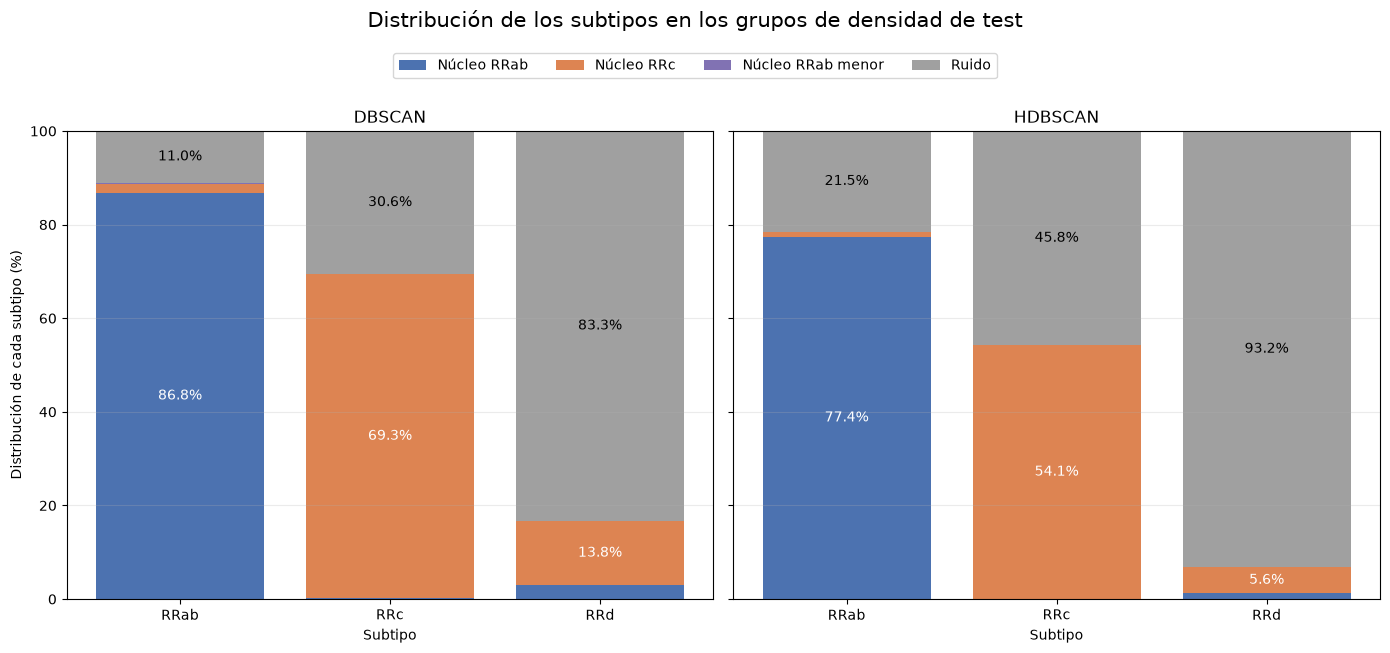

In [17]:
# Colores para los grupos de densidad
colores_densidad = {
    "Grupo 1": "#4C72B0",
    "Grupo 2": "#DD8452",
    "Grupo 3": "#8172B3",
    "Ruido": "#A0A0A0",
}

nombres_densidad = {
    "Grupo 1": "Núcleo RRab",
    "Grupo 2": "Núcleo RRc",
    "Grupo 3": "Núcleo RRab menor",
    "Ruido": "Ruido",
}

orden_subtipos = [
    "RRab",
    "RRc",
    "RRd",
]

orden_metodos = [
    "DBSCAN",
    "HDBSCAN",
]


fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 6),
    sharey=True,
)


for ax, metodo in zip(
    axes,
    orden_metodos,
):

    tabla_metodo = (
        tabla_distribucion_densidad_test
        .loc[
            tabla_distribucion_densidad_test[
                "metodo"
            ] == metodo
        ]
        .set_index("grupo")
    )

    orden_grupos = [
        grupo
        for grupo in [
            "Grupo 1",
            "Grupo 2",
            "Grupo 3",
            "Ruido",
        ]
        if grupo in tabla_metodo.index
    ]

    base = np.zeros(
        len(orden_subtipos)
    )

    for grupo in orden_grupos:

        valores = (
            tabla_metodo
            .loc[
                grupo,
                orden_subtipos,
            ]
            .to_numpy(
                dtype=float
            )
        )

        barras = ax.bar(
            orden_subtipos,
            valores,
            bottom=base,
            color=colores_densidad[grupo],
            label=nombres_densidad[grupo],
        )

        # Mostrar porcentajes relevantes
        for indice, valor in enumerate(valores):

            if valor >= 5:

                ax.text(
                    indice,
                    base[indice] + valor / 2,
                    f"{valor:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color=(
                        "white"
                        if grupo != "Ruido"
                        else "black"
                    ),
                )

        base = base + valores


    ax.set_title(
        metodo
    )

    ax.set_xlabel(
        "Subtipo"
    )

    ax.set_ylim(
        0,
        100,
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )


axes[0].set_ylabel(
    "Distribución de cada subtipo (%)"
)


# Construir una leyenda conjunta sin duplicados
handles = []
labels = []
vistos = set()

for ax in axes:

    handles_ax, labels_ax = (
        ax.get_legend_handles_labels()
    )

    for handle, label in zip(
        handles_ax,
        labels_ax,
    ):

        if label not in vistos:
            handles.append(handle)
            labels.append(label)
            vistos.add(label)


fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.02),
)


fig.suptitle(
    "Distribución de los subtipos en los grupos de densidad de test",
    fontsize=15,
    y=1.08,
)

plt.tight_layout()


plt.savefig(
    RUTA_RESULTADOS
    / "distribucion_subtipos_densidad_test.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Robustez entre ejecuciones de AA

Para comprobar que la estructura identificada no depende de una ejecución particular de AA, se aplican DBSCAN y HDBSCAN sobre los coeficientes \(\alpha\) obtenidos con las cinco semillas. Se mantienen fijos los parámetros seleccionados mediante validación y se evalúa la cobertura, la asociación con los subtipos y la proporción de cada subtipo identificada como ruido.

In [18]:



# ---------------------------------------------------------
# Configuración previamente seleccionada en validación
# ---------------------------------------------------------

MIN_SAMPLES_DBSCAN = 50
PERCENTIL_EPS_DBSCAN = 0.70

MIN_CLUSTER_SIZE_HDBSCAN = 500
MIN_SAMPLES_HDBSCAN = 10

ID_AA_REFERENCIA = "976409505a67e4f6"


# ---------------------------------------------------------
# Cargar las cinco ejecuciones de AA
# ---------------------------------------------------------

ruta_seleccion = (
    RUTA_PROYECTO
    / "resultados"
    / "seleccion_familias_test_corregida.csv"
)

ruta_artefactos_test = (
    RUTA_PROYECTO
    / "resultados"
    / "evaluacion_test_corregida"
    / "artefactos"
)

df_seleccion_robustez = pd.read_csv(ruta_seleccion)

df_aa_robustez = (
    df_seleccion_robustez.loc[
        df_seleccion_robustez["familia_test"]
        == "aa_principal_k5"
    ]
    .sort_values("seed_modelo")
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Recuperar el eps exacto seleccionado con validación
# ---------------------------------------------------------

fila_referencia = df_aa_robustez.loc[
    df_aa_robustez["experiment_id"].astype(str)
    == ID_AA_REFERENCIA
].iloc[0]

ruta_experimento_referencia = (
    RUTA_PROYECTO
    / Path(str(fila_referencia["ruta_experimento"]))
)

alphas_val_referencia = np.load(
    ruta_experimento_referencia / "alphas_val.npy"
)

vecinos = NearestNeighbors(
    n_neighbors=MIN_SAMPLES_DBSCAN
)

vecinos.fit(alphas_val_referencia)

distancias_val, _ = vecinos.kneighbors(
    alphas_val_referencia
)

eps_dbscan_fijo = np.quantile(
    distancias_val[:, -1],
    PERCENTIL_EPS_DBSCAN,
)

print(f"eps fijo de DBSCAN: {eps_dbscan_fijo:.6f}")


# ---------------------------------------------------------
# Funciones auxiliares
# ---------------------------------------------------------

def calcular_pureza(y_real, grupos):
    tabla = pd.crosstab(grupos, y_real)

    return (
        tabla.max(axis=1).sum()
        / tabla.to_numpy().sum()
    )


def evaluar_densidad(
    metodo,
    experiment_id,
    seed_modelo,
    alphas,
    grupos,
    subtipos,
):
    mascara_nucleo = grupos != -1
    grupos_validos = grupos[mascara_nucleo]

    n_grupos = len(
        set(grupos_validos.tolist())
    )

    cobertura = mascara_nucleo.mean()

    if mascara_nucleo.sum() > 0:
        pureza = calcular_pureza(
            subtipos[mascara_nucleo],
            grupos_validos,
        )

        ami_sin_ruido = adjusted_mutual_info_score(
            subtipos[mascara_nucleo],
            grupos_validos,
        )
    else:
        pureza = np.nan
        ami_sin_ruido = np.nan

    ami_total = adjusted_mutual_info_score(
        subtipos,
        grupos,
    )

    resultado = {
        "metodo": metodo,
        "experiment_id": experiment_id,
        "seed_modelo": seed_modelo,
        "n_grupos": n_grupos,
        "cobertura": cobertura,
        "pureza_sin_ruido": pureza,
        "ami_sin_ruido": ami_sin_ruido,
        "ami_total": ami_total,
    }

    for subtipo in ["RRab", "RRc", "RRd"]:
        mascara_subtipo = subtipos == subtipo

        resultado[
            f"{subtipo}_ruido_pct"
        ] = (
            100
            * np.mean(
                grupos[mascara_subtipo] == -1
            )
        )

    return resultado


# ---------------------------------------------------------
# Aplicar ambos métodos a las cinco ejecuciones
# ---------------------------------------------------------

subtipos_test = (
    metadata_test["subtipo_rrlyrae"]
    .astype(str)
    .to_numpy()
)

resultados_robustez = []
etiquetas_robustez = {}


for _, ejecucion in df_aa_robustez.iterrows():

    experiment_id = str(
        ejecucion["experiment_id"]
    )

    seed_modelo = int(
        ejecucion["seed_modelo"]
    )

    ruta_alphas_test = (
        ruta_artefactos_test
        / experiment_id
        / "alphas_test.npy"
    )

    alphas_test_semilla = np.load(
        ruta_alphas_test
    )

    if len(alphas_test_semilla) != len(subtipos_test):
        raise ValueError(
            f"La semilla {seed_modelo} no coincide "
            "con la cantidad de observaciones de test."
        )

    # DBSCAN con parámetros fijos
    grupos_dbscan = DBSCAN(
        eps=eps_dbscan_fijo,
        min_samples=MIN_SAMPLES_DBSCAN,
    ).fit_predict(alphas_test_semilla)

    etiquetas_robustez[
        ("DBSCAN", seed_modelo)
    ] = grupos_dbscan

    resultados_robustez.append(
        evaluar_densidad(
            metodo="DBSCAN",
            experiment_id=experiment_id,
            seed_modelo=seed_modelo,
            alphas=alphas_test_semilla,
            grupos=grupos_dbscan,
            subtipos=subtipos_test,
        )
    )

    # HDBSCAN con parámetros fijos
    grupos_hdbscan = HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE_HDBSCAN,
        min_samples=MIN_SAMPLES_HDBSCAN,
        cluster_selection_method="eom",
    ).fit_predict(alphas_test_semilla)

    etiquetas_robustez[
        ("HDBSCAN", seed_modelo)
    ] = grupos_hdbscan

    resultados_robustez.append(
        evaluar_densidad(
            metodo="HDBSCAN",
            experiment_id=experiment_id,
            seed_modelo=seed_modelo,
            alphas=alphas_test_semilla,
            grupos=grupos_hdbscan,
            subtipos=subtipos_test,
        )
    )


df_robustez_densidad = pd.DataFrame(
    resultados_robustez
)

display(
    df_robustez_densidad.round(4)
)

eps fijo de DBSCAN: 0.068738


c:\Users\adanm\Code\tesis\venv-tesis2\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
c:\Users\adanm\Code\tesis\venv-tesis2\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
c:\Users\adanm\Code\tesis\venv-tesis2\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
c:\Users\adanm\Code\tesis\venv-tesis2\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
c:\Users\ada

,metodo,experiment_id,seed_modelo,n_grupos,cobertura,pureza_sin_ruido,ami_sin_ruido,ami_total,RRab_ruido_pct,RRc_ruido_pct,RRd_ruido_pct
0,DBSCAN,130b477559867762,0,3,0.8169,0.9776,0.8238,0.5336,11.0207,30.5577,83.3076
1,HDBSCAN,130b477559867762,0,2,0.6998,0.9860,0.8813,0.4479,21.5283,45.8270,93.1994
2,DBSCAN,4dd949ada25b888e,1,3,0.8169,0.9776,0.8238,0.5336,11.0207,30.5577,83.3076
3,HDBSCAN,4dd949ada25b888e,1,2,0.6998,0.9860,0.8813,0.4479,21.5283,45.8270,93.1994
4,DBSCAN,37dedb2834a007b2,2,3,0.8166,0.9776,0.8241,0.5336,11.0275,30.6335,83.4621
5,HDBSCAN,37dedb2834a007b2,2,2,0.6993,0.9863,0.8826,0.4482,21.5488,45.9219,93.5085
6,DBSCAN,349e82cdd54799e0,3,3,0.8166,0.9776,0.8241,0.5336,11.0275,30.6335,83.4621
7,HDBSCAN,349e82cdd54799e0,3,2,0.6993,0.9863,0.8826,0.4482,21.5488,45.9219,93.5085
8,DBSCAN,976409505a67e4f6,4,3,0.8169,0.9776,0.8238,0.5336,11.0207,30.5577,83.3076
9,HDBSCAN,976409505a67e4f6,4,2,0.6998,0.9860,0.8813,0.4479,21.5283,45.8270,93.1994


In [20]:
comparaciones_robustez = []


for metodo in ["DBSCAN", "HDBSCAN"]:

    semillas_metodo = sorted(
        semilla
        for nombre_metodo, semilla
        in etiquetas_robustez.keys()
        if nombre_metodo == metodo
    )

    for semilla_a, semilla_b in combinations(
        semillas_metodo,
        2,
    ):

        grupos_a = etiquetas_robustez[
            (metodo, semilla_a)
        ]

        grupos_b = etiquetas_robustez[
            (metodo, semilla_b)
        ]

        ari = adjusted_rand_score(
            grupos_a,
            grupos_b,
        )

        coincidencia_ruido = np.mean(
            (grupos_a == -1)
            == (grupos_b == -1)
        )

        comparaciones_robustez.append(
            {
                "metodo": metodo,
                "semilla_a": semilla_a,
                "semilla_b": semilla_b,
                "ari_entre_semillas": ari,
                "coincidencia_ruido": coincidencia_ruido,
            }
        )


df_ari_robustez = pd.DataFrame(
    comparaciones_robustez
)


resumen_ari_robustez = (
    df_ari_robustez
    .groupby("metodo")
    .agg(
        n_comparaciones=(
            "ari_entre_semillas",
            "size",
        ),
        ari_medio=(
            "ari_entre_semillas",
            "mean",
        ),
        ari_minimo=(
            "ari_entre_semillas",
            "min",
        ),
        ari_maximo=(
            "ari_entre_semillas",
            "max",
        ),
        coincidencia_ruido_media=(
            "coincidencia_ruido",
            "mean",
        ),
        coincidencia_ruido_minima=(
            "coincidencia_ruido",
            "min",
        ),
    )
    .reset_index()
)


display(
    resumen_ari_robustez.round(6)
)

,metodo,n_comparaciones,ari_medio,ari_minimo,ari_maximo,coincidencia_ruido_media,coincidencia_ruido_minima
0,DBSCAN,10,0.999633,0.999388,1.0,0.999825,0.999708
1,HDBSCAN,10,0.999280,0.998800,1.0,0.999708,0.999513


### Robustez entre ejecuciones de AA

Las estructuras identificadas mediante DBSCAN y HDBSCAN se mantuvieron prácticamente invariantes entre las cinco ejecuciones de AA. DBSCAN alcanzó un ARI medio de 0,999633 entre semillas, con un mínimo de 0,999388, mientras que HDBSCAN obtuvo un ARI medio de 0,999280 y un mínimo de 0,998800. Además, la coincidencia respecto de las observaciones identificadas como ruido superó el 99,95 % en todas las comparaciones.

La relación con los subtipos también permaneció estable. DBSCAN clasificó como ruido entre el 83,31 % y el 83,46 % de las RRd, mientras que HDBSCAN identificó de esta manera entre el 93,20 % y el 93,51 %. Por lo tanto, la ubicación mayoritaria de las RRd fuera de los núcleos densos de RRab y RRc no depende de una ejecución particular de AA. Estos resultados describen una representación más dispersa o mixta dentro del espacio de coeficientes y no implican que las observaciones consideradas ruido correspondan necesariamente a datos defectuosos.

In [22]:
# ---------------------------------------------------------
# Directorios de salida
# ---------------------------------------------------------

RUTA_SALIDA_ALPHA = (
    RUTA_PROYECTO
    / "resultados"
    / "clustering_coeficientes_alpha"
)

RUTA_TABLAS_ALPHA = (
    RUTA_SALIDA_ALPHA
    / "tablas"
)

RUTA_ETIQUETAS_ALPHA = (
    RUTA_SALIDA_ALPHA
    / "etiquetas"
)

RUTA_TABLAS_ALPHA.mkdir(
    parents=True,
    exist_ok=True,
)

RUTA_ETIQUETAS_ALPHA.mkdir(
    parents=True,
    exist_ok=True,
)


archivos_guardados = []


# ---------------------------------------------------------
# Guardar las tablas pequeñas generadas en el notebook
# ---------------------------------------------------------

nombres_excluidos = {
    "metadata_val",
    "metadata_test",
    "df_seleccion",
    "df_seleccion_robustez",
    "df_aa_robustez",
}

for nombre, objeto in list(globals().items()):

    if nombre in nombres_excluidos:
        continue

    if isinstance(objeto, pd.Series):
        objeto = objeto.to_frame()

    if not isinstance(objeto, pd.DataFrame):
        continue

    # Las tablas de resultados son pequeñas.
    # Se omiten tablas por observación para evitar duplicaciones.
    if len(objeto) > 5000:
        continue

    ruta_archivo = (
        RUTA_TABLAS_ALPHA
        / f"{nombre}.csv"
    )

    objeto.to_csv(
        ruta_archivo,
        index=True,
    )

    archivos_guardados.append(
        {
            "archivo": str(
                ruta_archivo.relative_to(
                    RUTA_SALIDA_ALPHA
                )
            ),
            "tipo": "tabla",
            "filas": len(objeto),
            "columnas": len(objeto.columns),
        }
    )


# ---------------------------------------------------------
# Guardar identificadores y subtipos de test
# ---------------------------------------------------------

ids_test_clustering = (
    metadata_test["observacion_id"]
    .to_numpy()
)

np.save(
    RUTA_ETIQUETAS_ALPHA
    / "ids_test.npy",
    ids_test_clustering,
)

np.save(
    RUTA_ETIQUETAS_ALPHA
    / "subtipos_test.npy",
    subtipos_test,
)

archivos_guardados.extend(
    [
        {
            "archivo": "etiquetas/ids_test.npy",
            "tipo": "identificadores",
            "filas": len(ids_test_clustering),
            "columnas": 1,
        },
        {
            "archivo": "etiquetas/subtipos_test.npy",
            "tipo": "subtipos",
            "filas": len(subtipos_test),
            "columnas": 1,
        },
    ]
)


# ---------------------------------------------------------
# Guardar etiquetas de robustez para las cinco semillas
# ---------------------------------------------------------

for (
    metodo,
    semilla,
), etiquetas in etiquetas_robustez.items():

    nombre_archivo = (
        f"{metodo.lower()}_"
        f"seed_{semilla}_test.npy"
    )

    np.save(
        RUTA_ETIQUETAS_ALPHA
        / nombre_archivo,
        etiquetas,
    )

    archivos_guardados.append(
        {
            "archivo": (
                f"etiquetas/{nombre_archivo}"
            ),
            "tipo": "asignaciones_clustering",
            "filas": len(etiquetas),
            "columnas": 1,
        }
    )


# ---------------------------------------------------------
# Guardar otras asignaciones finales disponibles
# ---------------------------------------------------------

for nombre, objeto in list(globals().items()):

    nombre_minuscula = nombre.lower()

    es_asignacion = any(
        palabra in nombre_minuscula
        for palabra in [
            "grupo",
            "label",
            "etiqueta",
        ]
    )

    if not es_asignacion:
        continue

    if not isinstance(objeto, np.ndarray):
        continue

    if objeto.ndim != 1:
        continue

    if len(objeto) != len(metadata_test):
        continue

    nombre_archivo = f"{nombre}.npy"

    np.save(
        RUTA_ETIQUETAS_ALPHA
        / nombre_archivo,
        objeto,
    )

    ruta_relativa = (
        f"etiquetas/{nombre_archivo}"
    )

    if not any(
        registro["archivo"] == ruta_relativa
        for registro in archivos_guardados
    ):
        archivos_guardados.append(
            {
                "archivo": ruta_relativa,
                "tipo": "asignaciones_clustering",
                "filas": len(objeto),
                "columnas": 1,
            }
        )


# ---------------------------------------------------------
# Guardar la configuración seleccionada
# ---------------------------------------------------------

configuracion_clustering = {
    "unidad_analisis": "curva_de_luz",
    "representacion": "medianas_fase_50",
    "normalizacion_aa": "minmax",
    "numero_arquetipos": 5,
    "aa_experimento_representativo": (
        ID_AA_REFERENCIA
    ),
    "kmeans_alpha": {
        "K": 3,
        "seed_modelo": 1,
    },
    "dbscan": {
        "eps": float(eps_dbscan_fijo),
        "percentil_eps_validacion": (
            PERCENTIL_EPS_DBSCAN
        ),
        "min_samples": (
            MIN_SAMPLES_DBSCAN
        ),
    },
    "hdbscan": {
        "min_cluster_size": (
            MIN_CLUSTER_SIZE_HDBSCAN
        ),
        "min_samples": (
            MIN_SAMPLES_HDBSCAN
        ),
        "cluster_selection_method": "eom",
    },
    "nota_ruido": (
        "La etiqueta de ruido indica observaciones "
        "fuera de los núcleos densos y no implica "
        "necesariamente datos defectuosos."
    ),
}

ruta_configuracion = (
    RUTA_SALIDA_ALPHA
    / "configuracion_clustering.json"
)

with open(
    ruta_configuracion,
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        configuracion_clustering,
        archivo,
        ensure_ascii=False,
        indent=4,
    )

archivos_guardados.append(
    {
        "archivo": "configuracion_clustering.json",
        "tipo": "configuracion",
        "filas": np.nan,
        "columnas": np.nan,
    }
)


# ---------------------------------------------------------
# Crear manifiesto de archivos
# ---------------------------------------------------------

df_manifesto_alpha = pd.DataFrame(
    archivos_guardados
).drop_duplicates(
    subset="archivo"
).sort_values(
    ["tipo", "archivo"]
).reset_index(
    drop=True
)

df_manifesto_alpha.to_csv(
    RUTA_SALIDA_ALPHA
    / "manifesto_archivos.csv",
    index=False,
)


print(
    "Resultados guardados en:"
)

print(RUTA_SALIDA_ALPHA)

print(
    f"\nArchivos registrados: "
    f"{len(df_manifesto_alpha)}"
)

display(df_manifesto_alpha)

Resultados guardados en:
C:\Users\adanm\Code\tesis\resultados\clustering_coeficientes_alpha

Archivos registrados: 66


,archivo,tipo,filas,columnas
0,etiquetas/dbscan_seed_0_test.npy,asignaciones_clustering,20537.0,1.0
1,etiquetas/dbscan_seed_1_test.npy,asignaciones_clustering,20537.0,1.0
2,etiquetas/dbscan_seed_2_test.npy,asignaciones_clustering,20537.0,1.0
3,etiquetas/dbscan_seed_3_test.npy,asignaciones_clustering,20537.0,1.0
4,etiquetas/dbscan_seed_4_test.npy,asignaciones_clustering,20537.0,1.0
...,...,...,...,...
61,tablas\tabla_composicion_kmeans.csv,tabla,9.0,6.0
62,tablas\tabla_distancias_vecinos.csv,tabla,21.0,3.0
63,tablas\tabla_distribucion_densidad_test.csv,tabla,7.0,5.0
64,tablas\tabla_distribucion_kmeans.csv,tabla,9.0,5.0


## Conclusiones

El análisis de los coeficientes \(\alpha\) mostró que las asignaciones basadas en el coeficiente máximo conservan los cinco patrones definidos por los arquetipos, mientras que k-means aplicado al vector completo de coeficientes identifica estructuras más generales. La solución con tres grupos presentó el mejor equilibrio entre separación y estabilidad, pero no produjo un grupo específico para las RRd.

Los métodos basados en densidad identificaron dos núcleos principales asociados mayoritariamente con RRab y RRc. DBSCAN alcanzó una cobertura de 81,69 % y una pureza de 97,76 % entre las observaciones agrupadas, mientras que HDBSCAN obtuvo una cobertura de 69,98 % y una pureza de 98,60 %. En ambos casos, gran parte de las RRd quedó fuera de los núcleos densos: 83,31 % con DBSCAN y 93,20 % con HDBSCAN.

Las observaciones identificadas como ruido presentaron coeficientes más distribuidos entre varios arquetipos, reflejados en una menor dominancia y una mayor entropía. Por lo tanto, estos resultados sugieren que las RRd ocupan regiones más mixtas o menos densas del espacio de coeficientes, en lugar de formar un grupo compacto independiente.

La estructura obtenida resultó prácticamente invariante entre las cinco ejecuciones de AA. El ARI mínimo fue de 0,999388 para DBSCAN y de 0,998800 para HDBSCAN, mientras que la coincidencia mínima en la identificación del ruido superó el 99,95 %. Esto indica que los resultados no dependen de una semilla particular del modelo.

Finalmente, el pequeño grupo adicional de RRab detectado por DBSCAN debe considerarse un resultado exploratorio, ya que contiene solamente 59 observaciones y no fue recuperado por HDBSCAN. Su posible interpretación morfológica requiere un análisis específico posterior.